# Análise de Dados da COVID-19 em Curitiba

Este notebook tem como objetivo analisar os dados públicos da COVID-19 referentes à cidade de Curitiba. Vamos carregar os dados, limpá-los, explorar e visualizar as principais tendências.

Fonte: [Dados abertos Curitiba-PR](https://dadosabertos.curitiba.pr.gov.br/conjuntodado/)

## Casos Confirmados

In [ ]:
# Para trabalhar com mapas
!pip install geopandas

In [ ]:
# Importar Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.dates as mdates # Para formatar datas nos gráficos

# Configurações de visualização (opcional, mas melhora a aparência)
sns.set_style('whitegrid') # Estilo dos gráficos seaborn
plt.rcParams['figure.figsize'] = (15, 8) # Tamanho padrão das figuras matplotlib
pd.set_option('display.max_columns', 50) # Mostrar mais colunas do DataFrame
pd.set_option('display.width', 1000) # Ajustar largura do display do pandas

warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# Carregar o arquivo CSV
df_curitiba = pd.read_csv("/content/2025-11-06_Casos_Covid_19_-_Base_de_Dados.csv", sep=';', encoding='latin1')
print("Dados carregados com sucesso!")

Dados carregados com sucesso!


In [ ]:
print(f"Formato dos dados: {df_curitiba.shape[0]} linhas e {df_curitiba.shape[1]} colunas")

Formato dos dados: 655211 linhas e 10 colunas


In [ ]:
# Mostra as primeiras 5 linhas para inspeção inicial
print("\nPrimeiras 5 linhas dos dados:")
print(df_curitiba.head())


Primeiras 5 linhas dos dados:
  DATA INCLUSÃO/ NOTIFICAÇÃO CLASSIFICAÇÃO FINAL  IDADE (anos) SEXO      BAIRRO DISTRITO RESIDÊNCIA INTERNADO (SIM/NÃO) DATA COLETA EXAME DATA ÓBITO ENCERRAMENTO
0                 11/03/2020          CONFIRMADO            54    M  CRISTO REI                DSMZ                 NÃO        09/03/2020        NaN   RECUPERADO
1                 12/03/2020          CONFIRMADO            15    M       XAXIM                DSBQ                 NÃO        08/03/2020        NaN   RECUPERADO
2                 12/03/2020          CONFIRMADO            43    M       XAXIM                DSBQ                 NÃO        09/03/2020        NaN   RECUPERADO
3                 12/03/2020          CONFIRMADO            25    F  CRISTO REI                DSMZ                 NÃO        09/03/2020        NaN   RECUPERADO
4                 12/03/2020          CONFIRMADO            58    M      MERCÊS                DSMZ                 NÃO        09/03/2020        NaN   RECUPERA

In [ ]:
# Renomear colunas para facilitar o uso (minúsculas, sem espaços, acentos, caracteres especiais)

# Mostra nomes antes de renomear
print("Nomes originais:", df_curitiba.columns.tolist())

nomes_colunas_novos = {
    'DATA INCLUSÃO/ NOTIFICAÇÃO': 'data_notificacao',
    'CLASSIFICAÇÃO FINAL': 'classificacao_final',
    'IDADE (anos)': 'idade_anos',
    'SEXO': 'sexo',
    'BAIRRO': 'bairro',
    'DISTRITO RESIDÊNCIA': 'distrito_residencia',
    'INTERNADO (SIM/NÃO)': 'internado',
    'DATA COLETA EXAME': 'data_coleta_exame',
    'DATA ÓBITO': 'data_obito',
    'ENCERRAMENTO': 'encerramento'
}

df_curitiba.rename(columns=nomes_colunas_novos, inplace=True)
print("\nColunas renomeadas (sem espaços/acentos):")
print(df_curitiba.columns.tolist())

Nomes originais: ['DATA INCLUSÃO/ NOTIFICAÇÃO', 'CLASSIFICAÇÃO FINAL', 'IDADE (anos)', 'SEXO', 'BAIRRO', 'DISTRITO RESIDÊNCIA', 'INTERNADO (SIM/NÃO)', 'DATA COLETA EXAME', 'DATA ÓBITO', 'ENCERRAMENTO']

Colunas renomeadas (sem espaços/acentos):
['data_notificacao', 'classificacao_final', 'idade_anos', 'sexo', 'bairro', 'distrito_residencia', 'internado', 'data_coleta_exame', 'data_obito', 'encerramento']


In [ ]:
df_curitiba.head()

,data_notificacao,classificacao_final,idade_anos,sexo,bairro,distrito_residencia,internado,data_coleta_exame,data_obito,encerramento
0,11/03/2020,CONFIRMADO,54,M,CRISTO REI,DSMZ,NÃO,09/03/2020,NaN,RECUPERADO
1,12/03/2020,CONFIRMADO,15,M,XAXIM,DSBQ,NÃO,08/03/2020,NaN,RECUPERADO
2,12/03/2020,CONFIRMADO,43,M,XAXIM,DSBQ,NÃO,09/03/2020,NaN,RECUPERADO
3,12/03/2020,CONFIRMADO,25,F,CRISTO REI,DSMZ,NÃO,09/03/2020,NaN,RECUPERADO
4,12/03/2020,CONFIRMADO,58,M,MERCÊS,DSMZ,NÃO,09/03/2020,NaN,RECUPERADO


In [ ]:
# conversão para tipo datetime do pandas
df_curitiba['data_notificacao'] = pd.to_datetime(df_curitiba['data_notificacao'], dayfirst=True, errors='coerce')
df_curitiba['data_obito'] = pd.to_datetime(df_curitiba['data_obito'], dayfirst=True, errors='coerce')

In [ ]:
# verificar os tipos de dados
df_curitiba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 655211 entries, 0 to 655210
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   data_notificacao     655211 non-null  datetime64[ns]
 1   classificacao_final  655211 non-null  object        
 2   idade_anos           655211 non-null  int64         
 3   sexo                 655211 non-null  object        
 4   bairro               644314 non-null  object        
 5   distrito_residencia  644320 non-null  object        
 6   internado            655211 non-null  object        
 7   data_coleta_exame    655211 non-null  object        
 8   data_obito           8990 non-null    datetime64[ns]
 9   encerramento         655211 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(7)
memory usage: 50.0+ MB


In [ ]:
# Exploração Inicial dos Dados

print("\n---")
print("Resumo estatístico das colunas numéricas:")
print(df_curitiba.describe()) # Estatísticas descritivas (contagem, média, desvio padrão, etc.)

print("\n---")
print("Verificação de valores ausentes (NaN) por coluna:")
print(df_curitiba.isnull().sum())

print("\n---")
print("Nomes das colunas:")
print(df_curitiba.columns.tolist())


---
Resumo estatístico das colunas numéricas:
                    data_notificacao     idade_anos                     data_obito
count                         655211  655211.000000                           8990
mean   2022-01-07 15:47:55.484691968      40.022947  2021-05-23 07:03:49.855394304
min              2020-03-11 00:00:00       0.000000            2020-04-06 00:00:00
25%              2021-03-22 00:00:00      26.000000            2020-12-25 00:00:00
50%              2022-01-19 00:00:00      39.000000            2021-04-13 00:00:00
75%              2022-06-30 00:00:00      53.000000            2021-07-19 00:00:00
max              2025-10-31 00:00:00     107.000000            2025-10-28 00:00:00
std                              NaN      18.410500                            NaN

---
Verificação de valores ausentes (NaN) por coluna:
data_notificacao            0
classificacao_final         0
idade_anos                  0
sexo                        0
bairro                  10897
d

In [ ]:
df_curitiba.head()

,data_notificacao,classificacao_final,idade_anos,sexo,bairro,distrito_residencia,internado,data_coleta_exame,data_obito,encerramento
0,2020-03-11,CONFIRMADO,54,M,CRISTO REI,DSMZ,NÃO,09/03/2020,NaT,RECUPERADO
1,2020-03-12,CONFIRMADO,15,M,XAXIM,DSBQ,NÃO,08/03/2020,NaT,RECUPERADO
2,2020-03-12,CONFIRMADO,43,M,XAXIM,DSBQ,NÃO,09/03/2020,NaT,RECUPERADO
3,2020-03-12,CONFIRMADO,25,F,CRISTO REI,DSMZ,NÃO,09/03/2020,NaT,RECUPERADO
4,2020-03-12,CONFIRMADO,58,M,MERCÊS,DSMZ,NÃO,09/03/2020,NaT,RECUPERADO


In [ ]:
# incluir os valoes "Não registrado" para as colunas bairro e distrito_residencia
df_curitiba['bairro'].fillna('Não registrado', inplace=True)
df_curitiba['distrito_residencia'].fillna('Não registrado', inplace=True)

In [ ]:
print("\n---")
print("Verificação de valores ausentes (NaN) por coluna:")
print(df_curitiba.isnull().sum())


---
Verificação de valores ausentes (NaN) por coluna:
data_notificacao            0
classificacao_final         0
idade_anos                  0
sexo                        0
bairro                      0
distrito_residencia         0
internado                   0
data_coleta_exame           0
data_obito             646221
encerramento                0
dtype: int64


In [ ]:
# Total de bairros cadastrados como 'Não registrado'
print("\n---")
print("Total de bairros cadastrados como 'Não registrado':")
print(df_curitiba[df_curitiba['bairro'] == 'Não registrado'].shape[0])

print("\n---")
print("Total de bairros':")
print(df_curitiba[df_curitiba['bairro'] != 'Não registrado'].shape[0])

print("\n---")
print("Total de registros:")
print(df_curitiba.shape[0])


---
Total de bairros cadastrados como 'Não registrado':
10897

---
Total de bairros':
644314

---
Total de registros:
655211


In [ ]:
# Valores possíveis para coluna classificacao_final
print("\n---")
print("Valores possíveis para coluna classificacao_final:")
print(df_curitiba['classificacao_final'].unique())


---
Valores possíveis para coluna classificacao_final:
['CONFIRMADO']


In [ ]:
# Totalizando KPI
print("\n---")
print("Total de casos confirmados:")
print(df_curitiba[df_curitiba['classificacao_final'] == 'CONFIRMADO'].shape[0])


---
Total de casos confirmados:
655211


In [ ]:
# Média móvel 7 dias

# Agrupar os dados por data de notificação e contar os casos confirmados
casos_por_dia = df_curitiba[df_curitiba['classificacao_final'] == 'CONFIRMADO'].groupby('data_notificacao').size().reset_index(name='casos')

# Calcular a média móvel de 7 dias
casos_por_dia['media_movel_7d'] = casos_por_dia['casos'].rolling(window=7).mean()

# Exibir os resultados
print("\n---")
print("Média móvel últimos 7 dias:")
print(casos_por_dia['media_movel_7d'].tail(1))


---
Média móvel últimos 7 dias:
1895    7.857143
Name: media_movel_7d, dtype: float64


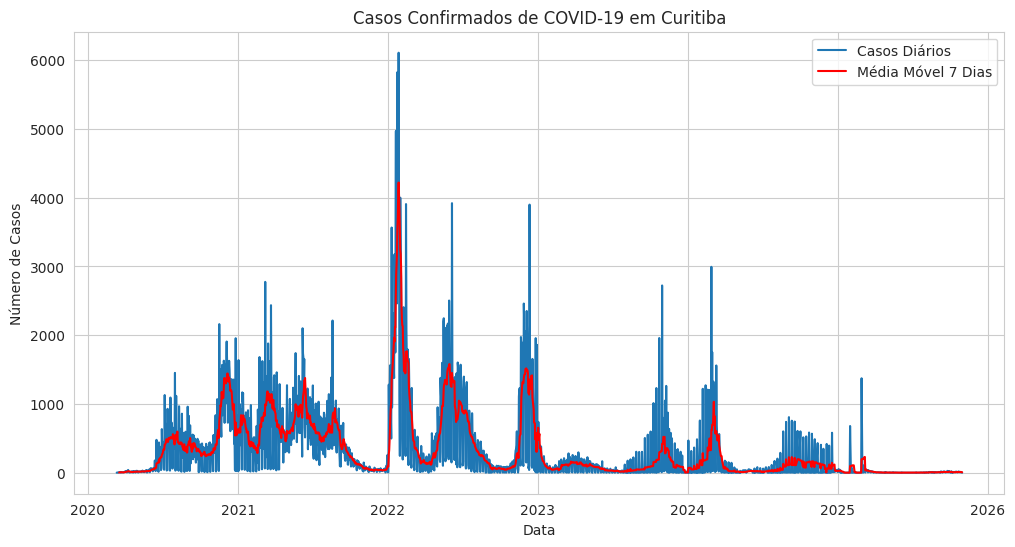

In [ ]:
# Plotar o gráfico da média móvel
plt.figure(figsize=(12, 6))
plt.plot(casos_por_dia['data_notificacao'], casos_por_dia['casos'], label='Casos Diários')
plt.plot(casos_por_dia['data_notificacao'], casos_por_dia['media_movel_7d'], label='Média Móvel 7 Dias', color='red')
plt.xlabel('Data')
plt.ylabel('Número de Casos')
plt.title('Casos Confirmados de COVID-19 em Curitiba')
plt.legend()
plt.grid(True)
plt.show()

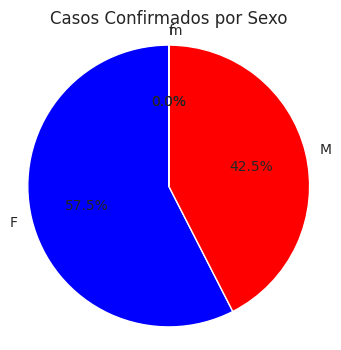

In [ ]:
# Gráfico de Casos confirmados por sexo.

# Agrupar os dados por sexo e contar os casos confirmados
casos_por_sexo = df_curitiba[df_curitiba['classificacao_final'] == 'CONFIRMADO'].groupby('sexo').size().reset_index(name='casos')

# Criar o gráfico de pizza
plt.figure(figsize=(4, 4))
plt.pie(casos_por_sexo['casos'], labels=casos_por_sexo['sexo'], autopct='%1.1f%%', startangle=90, colors=['blue', 'red'])
plt.title('Casos Confirmados por Sexo')
plt.axis('equal')  # Para garantir um círculo perfeito
plt.show()

In [ ]:
# Procurando outros valores
df_curitiba.sexo.value_counts()

,count
sexo,
F,376863
M,278345
m,2
f,1


In [ ]:
# Convertendo todos os valores da coluna 'sexo' para maiúsculas
df_curitiba['sexo'] = df_curitiba['sexo'].str.upper()

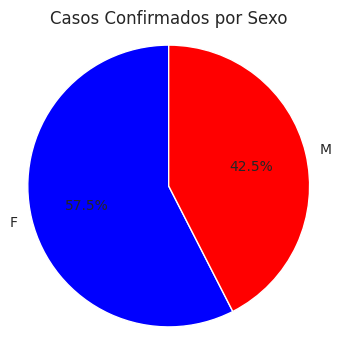

In [ ]:
# Gráfico de Casos confirmados por sexo.

# Agrupar os dados por sexo e contar os casos confirmados
casos_por_sexo = df_curitiba[df_curitiba['classificacao_final'] == 'CONFIRMADO'].groupby('sexo').size().reset_index(name='casos')

# Criar o gráfico de pizza
plt.figure(figsize=(4, 4))
plt.pie(casos_por_sexo['casos'], labels=casos_por_sexo['sexo'], autopct='%1.1f%%', startangle=90, colors=['blue', 'red'])
plt.title('Casos Confirmados por Sexo')
plt.axis('equal')  # Para garantir um círculo perfeito
plt.show()

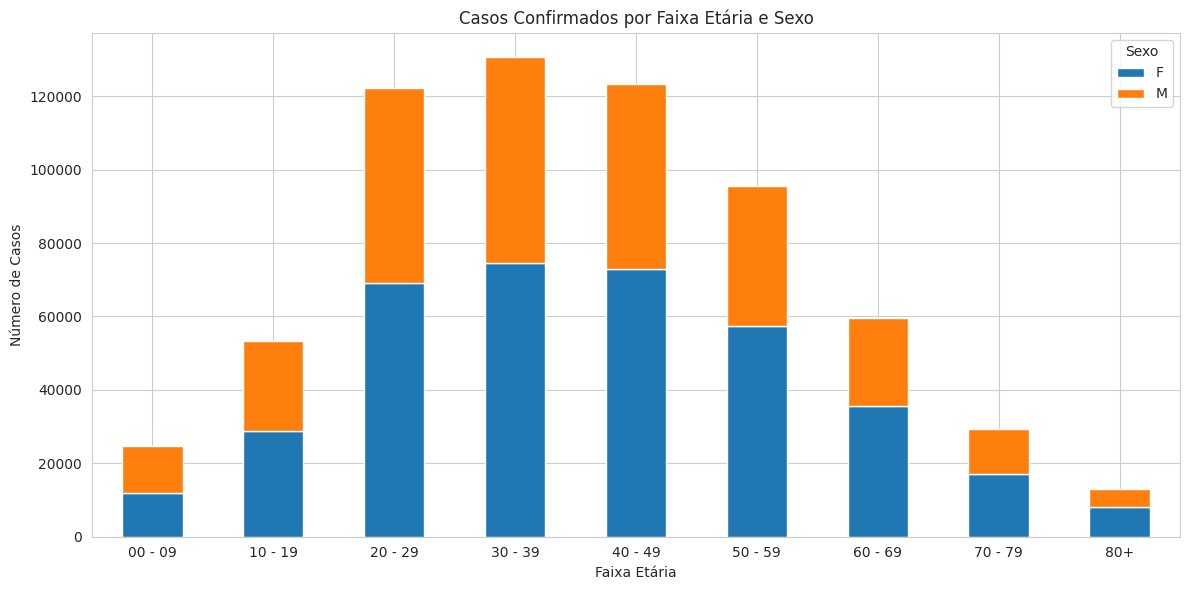

In [ ]:
# Gráfico de barras empilhada para os casos confirmados por Faixa Etária e Sexo.
# Faixas 00-09, 10-19, 20-29, 30-39, 40-49, 50-59, 60-69, 70-79, 80 >=

# Criar faixas etárias
faixas_etarias = [0, 9, 19, 29, 39, 49, 59, 69, 79, float('inf')]
labels_faixas = ['00 - 09', '10 - 19', '20 - 29', '30 - 39', '40 - 49', '50 - 59', '60 - 69', '70 - 79', '80+']
df_curitiba['faixa_etaria'] = pd.cut(df_curitiba['idade_anos'], bins=faixas_etarias, labels=labels_faixas, right=True)

# Agrupar por faixa etária e sexo, contando os casos confirmados
casos_por_faixa_sexo = df_curitiba[df_curitiba['classificacao_final'] == 'CONFIRMADO'].groupby(['faixa_etaria', 'sexo']).size().unstack(fill_value=0)

# Criar o gráfico de barras empilhadas
casos_por_faixa_sexo.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Casos Confirmados por Faixa Etária e Sexo')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Casos')
plt.xticks(rotation=0) # Rotacionar os rótulos do eixo x para melhor legibilidade
plt.legend(title='Sexo')
plt.tight_layout() # Ajustar o layout para evitar sobreposição de elementos
plt.show()

In [ ]:
# Alterando todos os valores para Caixa Alta
df_curitiba['sexo'].unique()

df_curitiba['sexo'] = df_curitiba['sexo'].str.upper()

df_curitiba['sexo'].unique()

array(['M', 'F'], dtype=object)

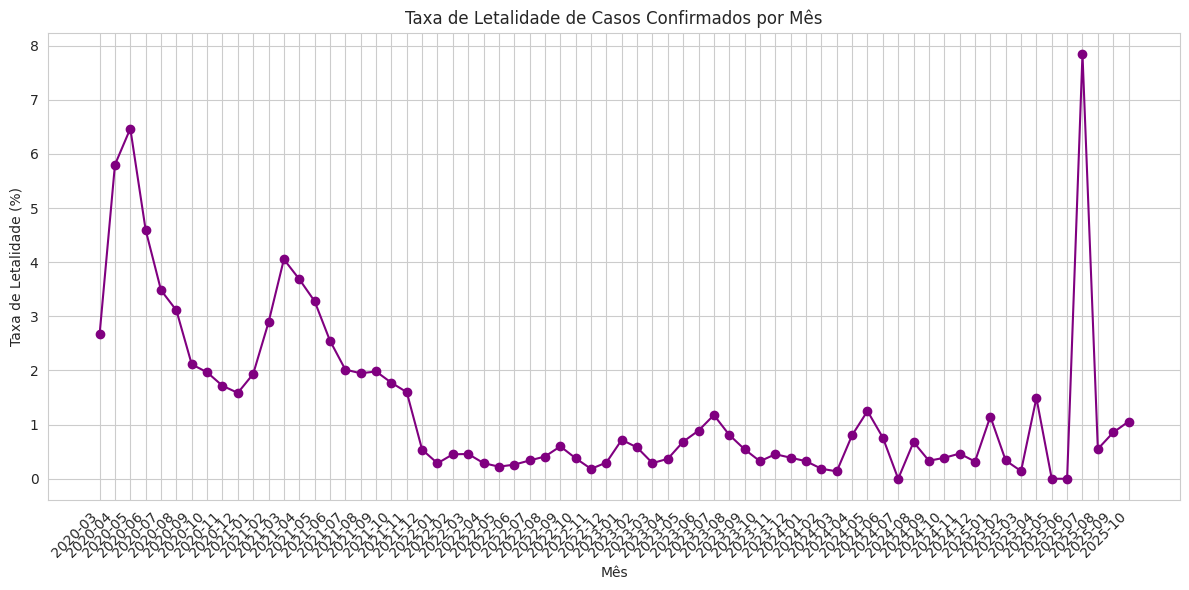

In [ ]:
#Gráfico de linhas com a taxa de letalidade.

# Criar uma cópia do DataFrame para evitar modificações no original
df_letalidade = df_curitiba.copy()

# Converter a coluna 'data_notificacao' para o tipo datetime, tratando possíveis erros
df_letalidade['data_notificacao'] = pd.to_datetime(df_letalidade['data_notificacao'], errors='coerce')

# Criar colunas para o mês e o ano da notificação
df_letalidade['mes_ano'] = df_letalidade['data_notificacao'].dt.to_period('M')

# Filtrar apenas os casos confirmados
casos_confirmados = df_letalidade[df_letalidade['classificacao_final'] == 'CONFIRMADO']

# Agrupar por mês/ano e contar os casos confirmados e óbitos
letalidade_por_mes = casos_confirmados.groupby('mes_ano').agg(
    casos_confirmados=('classificacao_final', 'count'),
    obitos=('data_obito', lambda x: x.notnull().sum())
).reset_index()

# Calcular a taxa de letalidade
letalidade_por_mes['taxa_letalidade'] = (letalidade_por_mes['obitos'] / letalidade_por_mes['casos_confirmados']) * 100

# Criar o gráfico de linhas
plt.figure(figsize=(12, 6))
plt.plot(letalidade_por_mes['mes_ano'].astype(str), letalidade_por_mes['taxa_letalidade'], marker='o', color='purple')
plt.title('Taxa de Letalidade de Casos Confirmados por Mês')
plt.xlabel('Mês')
plt.ylabel('Taxa de Letalidade (%)')
plt.title('Taxa de Letalidade de Casos Confirmados por Mês')
plt.xticks(rotation=45, ha='right')  # Rotacionar os rótulos do eixo x para melhor legibilidade
plt.grid(True)
plt.tight_layout()
plt.show()

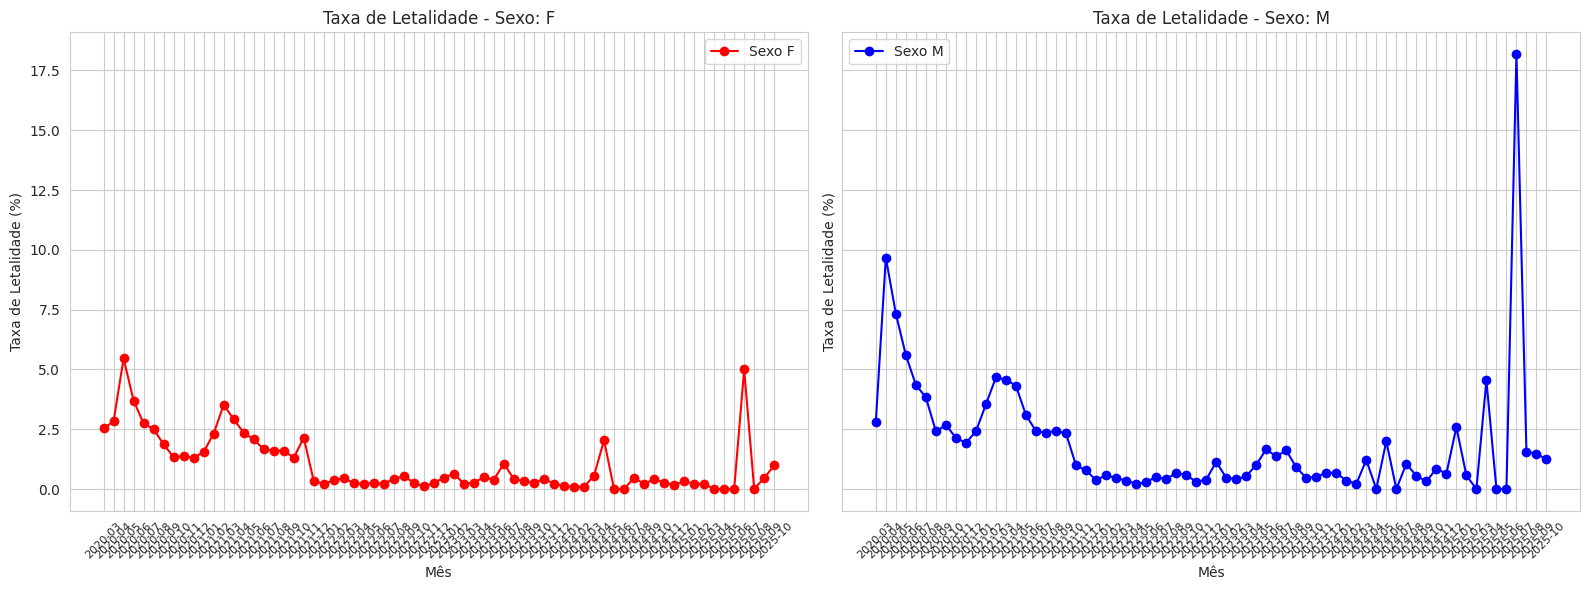

In [ ]:
# Criar uma cópia do DataFrame
df_letalidade_sexo = df_curitiba.copy()

df_letalidade_sexo['data_notificacao'] = pd.to_datetime(df_letalidade_sexo['data_notificacao'], errors='coerce')

df_letalidade_sexo['mes_ano'] = df_letalidade_sexo['data_notificacao'].dt.to_period('M')

casos_confirmados_sexo = df_letalidade_sexo[df_letalidade_sexo['classificacao_final'] == 'CONFIRMADO']

letalidade_por_mes_sexo = casos_confirmados_sexo.groupby(['mes_ano', 'sexo']).agg(
    casos_confirmados=('classificacao_final', 'count'),
    obitos=('data_obito', lambda x: x.notnull().sum())
).reset_index()

letalidade_por_mes_sexo['taxa_letalidade'] = (letalidade_por_mes_sexo['obitos'] / letalidade_por_mes_sexo['casos_confirmados']) * 100

# Cores por sexo
cores = {'F': 'red', 'M': 'blue'}

sexos = ['F', 'M']
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, sexo in zip(axes, sexos):
    subset = letalidade_por_mes_sexo[letalidade_por_mes_sexo['sexo'] == sexo]
    ax.plot(subset['mes_ano'].astype(str), subset['taxa_letalidade'], marker='o', color=cores[sexo], label=f'Sexo {sexo}')
    ax.set_title(f'Taxa de Letalidade - Sexo: {sexo}')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Taxa de Letalidade (%)')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

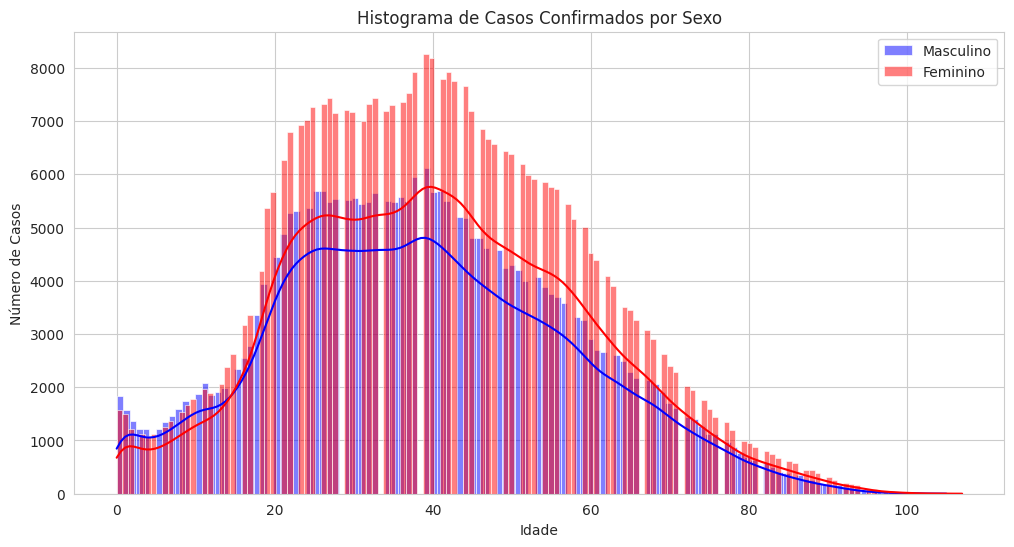

In [ ]:
# Gráfico de histograma dos casos confirmados por sexo
plt.figure(figsize=(12, 6))

# Filtrar apenas os casos confirmados
casos_confirmados = df_curitiba[df_curitiba['classificacao_final'] == 'CONFIRMADO']


sns.histplot(casos_confirmados[casos_confirmados['sexo'] == 'M']['idade_anos'], label='Masculino', kde=True, color='blue')
sns.histplot(casos_confirmados[casos_confirmados['sexo'] == 'F']['idade_anos'], label='Feminino', kde=True, color='red')

plt.title('Histograma de Casos Confirmados por Sexo')
plt.xlabel('Idade')
plt.ylabel('Número de Casos')
plt.legend()
plt.show()

In [ ]:
# Agrupa por classificação e conta as ocorrências
casos_confirmados_por_bairro = df_curitiba[df_curitiba['classificacao_final'] == 'CONFIRMADO'].groupby('bairro').size().reset_index(name='Total de Casos')

# Ordena o DataFrame pela coluna 'Total de Casos' em ordem decrescente
casos_confirmados_por_bairro_ordenado = casos_confirmados_por_bairro.sort_values(by='Total de Casos', ascending=False)

# Exibe a tabela
casos_confirmados_por_bairro_ordenado


,bairro,Total de Casos
28,CIDADE INDUSTRIAL DE CURITIBA,64358
65,SÍTIO CERCADO,40958
18,CAJURU,33428
70,UBERABA,26286
14,BOQUEIRÃO,26248
...,...,...
66,TABOÃO,990
24,CASCATINHA,930
64,SÃO MIGUEL,838
41,LAMENHA PEQUENA,249


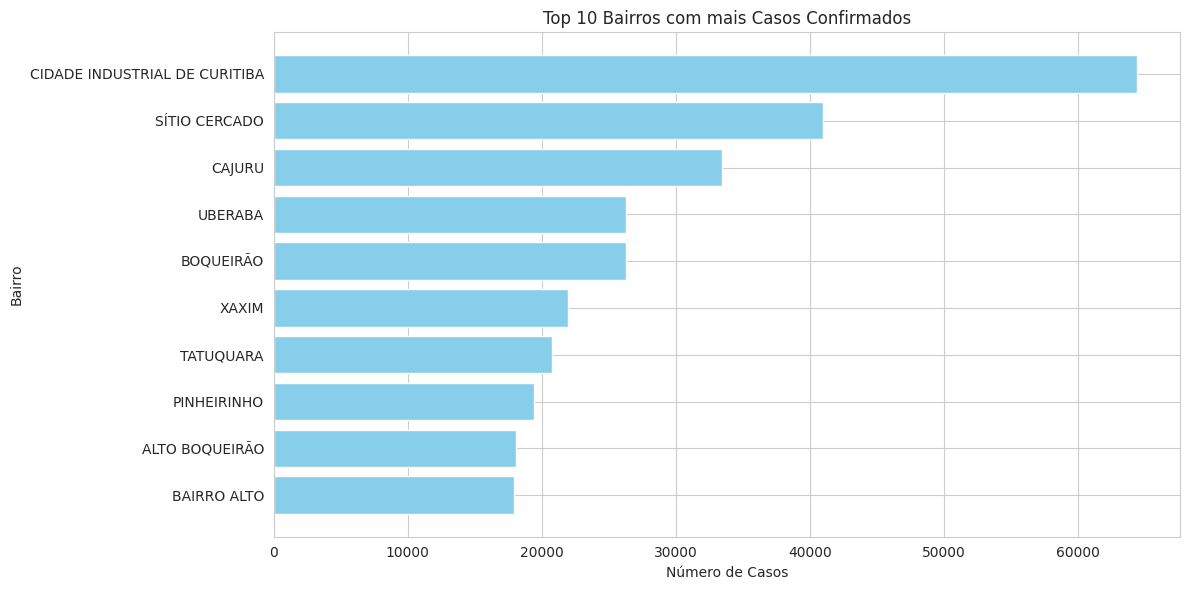

In [ ]:
# Gráfico 10 bairros com mais casos confirmados

# Filtrar os 10 bairros com mais casos
top_10_bairros = casos_confirmados_por_bairro_ordenado.head(10)

# Criar o gráfico de barras horizontais
plt.figure(figsize=(12, 6))
plt.barh(top_10_bairros['bairro'], top_10_bairros['Total de Casos'], color='skyblue')
plt.xlabel('Número de Casos')
plt.ylabel('Bairro')
plt.title('Top 10 Bairros com mais Casos Confirmados')
plt.gca().invert_yaxis()  # Inverter o eixo y para ordenar do maior para o menor
plt.tight_layout()
plt.show()

In [ ]:
casos_confirmados_por_bairro.head()

,bairro,Total de Casos
0,ABRANCHES,58
1,AHÚ,45
2,ALTO BOQUEIRÃO,244
3,ALTO DA GLÓRIA,40
4,ALTO DA RUA XV,46


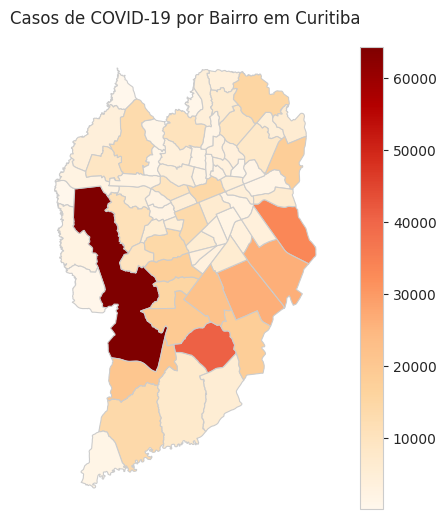

In [ ]:
# mapa de curitba e pinte os bairros de acordo com a quantidade de casos

import geopandas as gpd

curitiba_map = gpd.read_file('/content/DIVISA_DE_BAIRROS.dbf')
curitiba_map.rename(columns={'NOME': 'bairro'}, inplace=True)


# join por bairro
merged_data = curitiba_map.merge(casos_confirmados_por_bairro, on='bairro', how='left')


# figura para o mapa
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

merged_data.plot(column='Total de Casos', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# plotar o mapa
ax.set_title('Casos de COVID-19 por Bairro em Curitiba')
ax.set_axis_off()

plt.show()


## Óbitos

Complemente esta parte do exercício.

Total de Óbitos

Gráfico - Evolução de óbitos e Média Movel de 7 dias

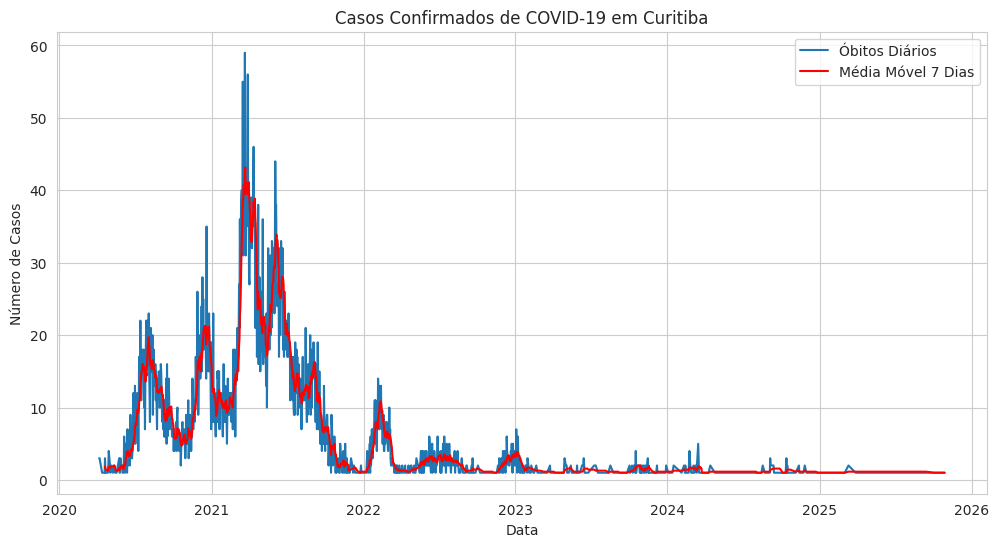

In [ ]:
# Média móvel de 7 dias para os casos de óbitos

# Agrupar os dados por data de notificação e contar os casos confirmados
casos_obito_dia = df_curitiba[df_curitiba['encerramento'] == 'ÓBITO CONF'].groupby('data_obito').size().reset_index(name='casos')

# Calcular a média móvel de 7 dias
casos_obito_dia['media_movel_7d'] = casos_obito_dia['casos'].rolling(window=7).mean()

# Exibir os resultados
#print(casos_obito_dia)

# Plotar o gráfico da média móvel
plt.figure(figsize=(12, 6))
plt.plot(casos_obito_dia['data_obito'], casos_obito_dia['casos'], label='Óbitos Diários')
plt.plot(casos_obito_dia['data_obito'], casos_obito_dia['media_movel_7d'], label='Média Móvel 7 Dias', color='red')
plt.xlabel('Data')
plt.ylabel('Número de Casos')
plt.title('Casos Confirmados de COVID-19 em Curitiba')
plt.legend()
plt.grid(True)
plt.show()

Gráfico - Óbitos confirmados por Sexo

In [ ]:
df_curitiba.head(1)

,data_notificacao,classificacao_final,idade_anos,sexo,bairro,distrito_residencia,internado,data_coleta_exame,data_obito,encerramento,faixa_etaria
0,2020-03-11,CONFIRMADO,54,M,CRISTO REI,DSMZ,NÃO,09/03/2020,NaT,RECUPERADO,50 - 59


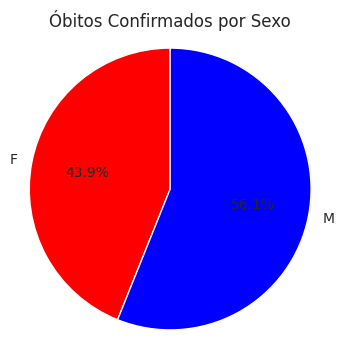

In [ ]:
# Gráfico de Casos confirmados por sexo.


# Agrupar os dados por sexo e contar os casos confirmados
obitos_por_sexo = df_curitiba[df_curitiba['encerramento'] == 'ÓBITO CONF'].groupby('sexo').size().reset_index(name='casos')

# Criar o gráfico de pizza
plt.figure(figsize=(4, 4))
plt.pie(obitos_por_sexo['casos'], labels=obitos_por_sexo['sexo'], autopct='%1.1f%%', startangle=90, colors=['red', 'blue'])
plt.title('Óbitos Confirmados por Sexo')
plt.axis('equal')  # Para garantir um círculo perfeito
plt.show()

Óbitos Confirmados por Faixa Etária e Sexo

Continuar as demais análises

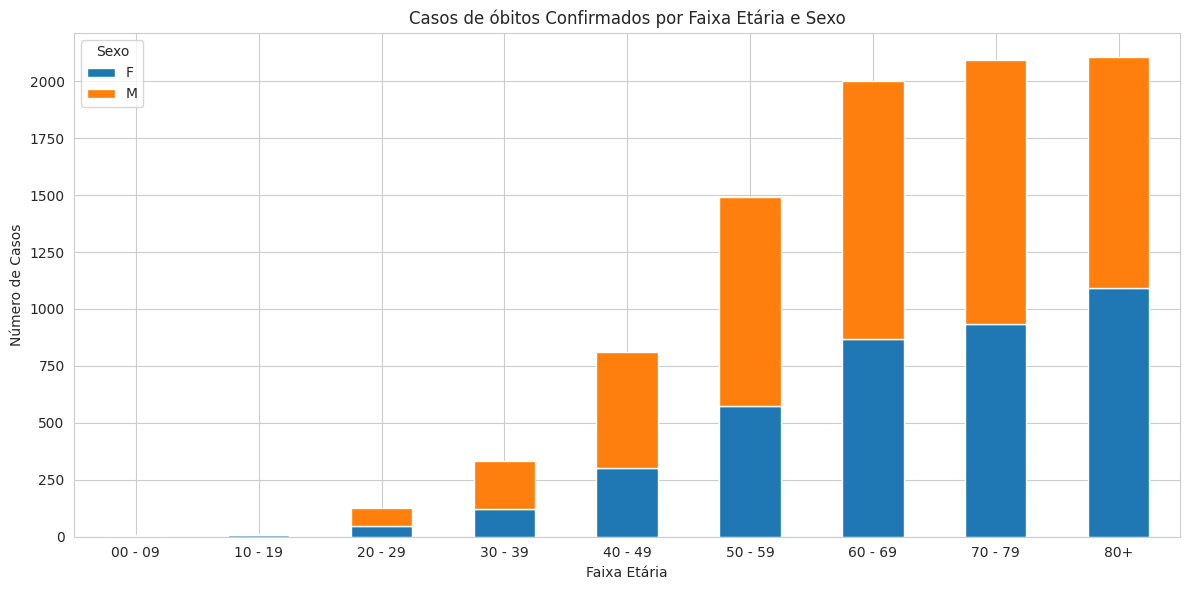

In [ ]:
# Gráfico de barras empilhada para os casos confirmados por Faixa Etária e Sexo.
# Faixas 00-09, 10-19, 20-29, 30-39, 40-49, 50-59, 60-69, 70-79, 80 >=

# Criar faixas etárias
faixas_etarias = [0, 9, 19, 29, 39, 49, 59, 69, 79, float('inf')]
labels_faixas = ['00 - 09', '10 - 19', '20 - 29', '30 - 39', '40 - 49', '50 - 59', '60 - 69', '70 - 79', '80+']
df_curitiba['faixa_etaria'] = pd.cut(df_curitiba['idade_anos'], bins=faixas_etarias, labels=labels_faixas, right=True)

# Agrupar por faixa etária e sexo, contando os casos confirmados
casos_por_faixa_sexo = df_curitiba[df_curitiba['encerramento'] == 'ÓBITO CONF'].groupby(['faixa_etaria', 'sexo']).size().unstack(fill_value=0)

# Criar o gráfico de barras empilhadas
casos_por_faixa_sexo.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Casos de óbitos Confirmados por Faixa Etária e Sexo')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Casos')
plt.xticks(rotation=0) # Rotacionar os rótulos do eixo x para melhor legibilidade
plt.legend(title='Sexo')
plt.tight_layout() # Ajustar o layout para evitar sobreposição de elementos

In [ ]:
plt.figure(figsize=(10, 6))

casos_confirmados = df_curitiba[df_curitiba['encerramento'] == 'ÓBITO CONF']

sns.histplot(casos_confirmados[casos_confirmados['sexo'] == 'M']['idade_anos'], label='Masculino', kde=True, color='blue')
sns.histplot(casos_confirmados[casos_confirmados['sexo'] == 'F']['idade_anos'], label='Feminino', kde=True, color='red')

plt.title('Histograma de Casos Confirmados de Óbitos por Sexo')
plt.xlabel('Idade')
plt.ylabel('Número de Casos')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Agrupa por classificação e conta as ocorrências
casos_confirmados_por_bairro = df_curitiba[df_curitiba['encerramento'] == 'ÓBITO CONF'].groupby('bairro').size().reset_index(name='Total de Casos')

# Ordena o DataFrame pela coluna 'Total de Casos' em ordem decrescente
casos_confirmados_por_bairro_ordenado = casos_confirmados_por_bairro.sort_values(by='Total de Casos', ascending=False)

# Exibe a tabela
casos_confirmados_por_bairro_ordenado


,bairro,Total de Casos
28,CIDADE INDUSTRIAL DE CURITIBA,860
65,SÍTIO CERCADO,567
18,CAJURU,563
14,BOQUEIRÃO,420
70,UBERABA,343
...,...,...
25,CAXIMBA,11
64,SÃO MIGUEL,11
41,LAMENHA PEQUENA,2
46,Não registrado,2


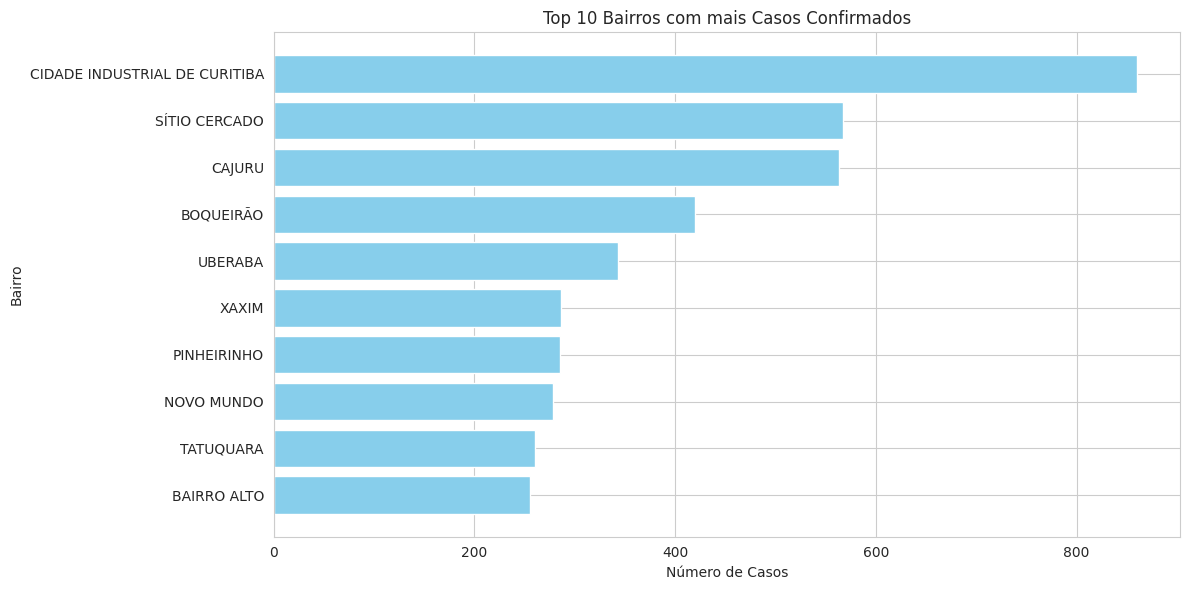

In [ ]:
# Gráfico 10 bairros com mais casos confirmados

# Filtrar os 10 bairros com mais casos
top_10_bairros = casos_confirmados_por_bairro_ordenado.head(10)

# Criar o gráfico de barras horizontais
plt.figure(figsize=(12, 6))
plt.barh(top_10_bairros['bairro'], top_10_bairros['Total de Casos'], color='skyblue')
plt.xlabel('Número de Casos')
plt.ylabel('Bairro')
plt.title('Top 10 Bairros com mais Casos Confirmados')
plt.gca().invert_yaxis()  # Inverter o eixo y para ordenar do maior para o menor
plt.tight_layout()
plt.show()

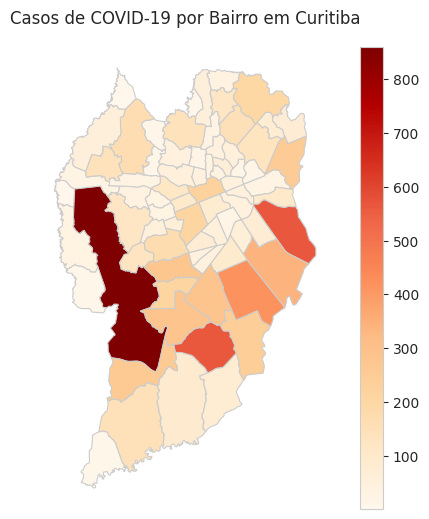

In [ ]:
# mapa de curitba e pinte os bairros de acordo com a quantidade de casos

import geopandas as gpd

curitiba_map = gpd.read_file('/content/DIVISA_DE_BAIRROS.dbf')
curitiba_map.rename(columns={'NOME': 'bairro'}, inplace=True)


# join por bairro
merged_data = curitiba_map.merge(casos_confirmados_por_bairro, on='bairro', how='left')


# figura para o mapa
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

merged_data.plot(column='Total de Casos', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# plotar o mapa
ax.set_title('Casos de COVID-19 por Bairro em Curitiba')
ax.set_axis_off()

plt.show()
